# Context Engineering & Ambiguity Demo

Este notebook interactivo demuestra los conceptos explicados en la presentación sobre **Context Engineering**.

Aplicaremos:
1. Construcción de un almacén vectorial (Vector Store).
2. Recuperación directa RAG mostrando el problema de la ambigüedad ($\Delta \approx 0$).
3. Resolución de ambigüedad mediante una política de clarificación (identificación de intención latente $Z$).


## 1. Configuración de Entorno e Instalación de Dependencias
Ejecuta la siguiente celda para instalar las herramientas open-source necesarias (LangChain, OpenAI SDK, FAISS, Matplotlib).


In [ ]:
!pip install -qU langchain langchain-openai langchain-community faiss-cpu python-dotenv matplotlib numpy



Cargamos las variables de entorno desde el archivo `.env` (asegúrate de haber colocado tu `OPENAI_API_KEY` allí).


In [16]:
import os
from dotenv import load_dotenv

# Cargar configuración (OPENAI_API_KEY)
load_dotenv()

if not os.environ.get("OPENAI_API_KEY"):
    print("⚠️ ADVERTENCIA: No se encontró OPENAI_API_KEY. Por favor, edita el archivo .env.")
else:
    print("✅ Clave de OpenAI cargada correctamente.")



✅ Clave de OpenAI cargada correctamente.


## 2. Creación del Almacén Vectorial (Base de Conocimiento)

Vamos a crear una base de datos vectorial que contenga dos clústeres de información muy distintos referidos a un mismo concepto polisémico: **Memoria**.
- **Clúster A (Intención Z1):** Memoria computacional (Hardware / RAM).
- **Clúster B (Intención Z2):** Memoria de agentes conversacionales (IA / LLMs).


In [17]:
from langchain_openai import OpenAIEmbeddings
from langchain_community.vectorstores import FAISS
from langchain_core.documents import Document

# Definimos los documentos del conocimiento
documents = [
    # Clúster Hardware (RAM)
    Document(page_content="La memoria RAM (Random Access Memory) es el hardware volátil donde el procesador de un computador almacena los datos en uso y las instrucciones de los programas en ejecución.", metadata={"topic": "hardware"}),
    Document(page_content="Para actualizar la memoria RAM, asegúrese de apagar el equipo y verificar el estándar compatible (ej. DDR4 o DDR5) en la placa base.", metadata={"topic": "hardware"}),
    Document(page_content="El cuello de botella del sistema suele reducirse aumentando la capacidad de la memoria RAM del ordenador portátil.", metadata={"topic": "hardware"}),
    
    # Clúster Inteligencia Artificial (Agentes)
    Document(page_content="En agentes conversacionales, la memoria es un componente de software que almacena el historial del chat para mantener el contexto de la conversación activa a largo plazo.", metadata={"topic": "ai_agents"}),
    Document(page_content="La memoria de los LLM (como LangChain Memory) permite inyectar interacciones pasadas en el prompt para evitar que el agente olvide instrucciones previas.", metadata={"topic": "ai_agents"}),
    Document(page_content="Para mejorar el contexto de la memoria del agente, se utilizan resúmenes periódicos y recuperación semántica de la base de datos de los mensajes del usuario.", metadata={"topic": "ai_agents"})
]

# Inicializamos el extractor de embeddings de OpenAI
embeddings = OpenAIEmbeddings(model="text-embedding-3-small")

# Creamos el almacén vectorial FAISS en memoria
vector_store = FAISS.from_documents(documents, embeddings)
retriever = vector_store.as_retriever(search_kwargs={"k": 4})

print("✅ Base de conocimiento vectorial construida.")



✅ Base de conocimiento vectorial construida.


## 3. El Cuello de Botella de la Ambigüedad ($X$)

Imagina que un usuario envía una consulta altamente ambigua sin contexto adicional. Probaremos con la consulta: **"¿Cómo funciona la memoria?"**

Veremos cómo el modelo recupera información mezclada (ruido vs señal) provocando que el margen de similitud $\Delta$ sea casi nulo.


Resultados de búsqueda para la consulta: '¿Cómo funciona la memoria?'

Doc 1 [hardware] (Score L2: 0.7764 | Cosine: 0.6118): La memoria RAM (Random Access Memory) es el hardware volátil donde el ...
Doc 2 [ai_agents] (Score L2: 1.0326 | Cosine: 0.4837): La memoria de los LLM (como LangChain Memory) permite inyectar interac...
Doc 3 [ai_agents] (Score L2: 1.0824 | Cosine: 0.4588): En agentes conversacionales, la memoria es un componente de software q...
Doc 4 [hardware] (Score L2: 1.0893 | Cosine: 0.4553): Para actualizar la memoria RAM, asegúrese de apagar el equipo y verifi...
Doc 5 [hardware] (Score L2: 1.1043 | Cosine: 0.4479): El cuello de botella del sistema suele reducirse aumentando la capacid...
Doc 6 [ai_agents] (Score L2: 1.1860 | Cosine: 0.4070): Para mejorar el contexto de la memoria del agente, se utilizan resúmen...


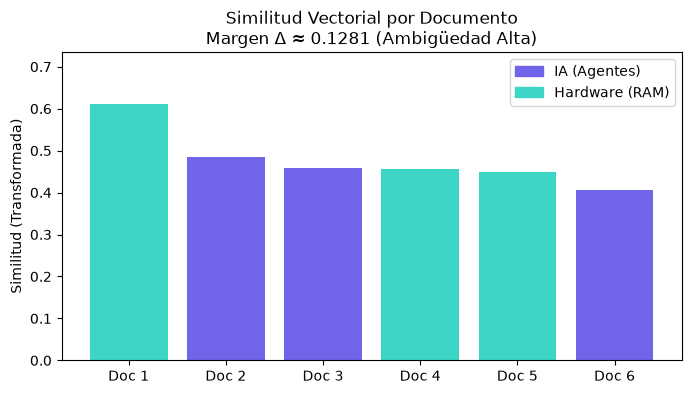

CONCLUSIÓN: El sistema recupera documentos de ambos tópicos con un score muy similar. El contexto orquestado estará contaminado (Alta Entropía H).


In [18]:
import numpy as np
import matplotlib.pyplot as plt

ambiguous_query = "¿Cómo funciona la memoria?"

# Recuperar documentos junto con sus scores de similitud
# En FAISS usamos similarity_search_with_score (devuelve distancia L2, donde menor es más similar)
results = vector_store.similarity_search_with_score(ambiguous_query, k=6)

docs = []
scores = []
topics = []

print(f"Resultados de búsqueda para la consulta: '{ambiguous_query}'\n")
for i, (doc, score) in enumerate(results):
    docs.append(f"Doc {i+1}")
    # FAISS devuelve la distancia L2 al cuadrado. Para vectores normalizados (OpenAI), podemos convertir a Similitud Coseno:
    # Cosine Similarity = 1 - (L2_Distance^2 / 2)
    similarity = 1 - (score / 2)
    scores.append(similarity)
    topics.append(doc.metadata["topic"])
    print(f"Doc {i+1} [{doc.metadata['topic']}] (Score L2: {score:.4f} | Cosine: {similarity:.4f}): {doc.page_content[:70]}...")

# Gráfico de similitudes (Margen Delta)
plt.figure(figsize=(8, 4))
colors = ['#7065E8' if t == 'ai_agents' else '#3DD6C6' for t in topics]
bars = plt.bar(docs, scores, color=colors)

# Calcular Delta real entre la mejor coincidencia de IA y la mejor de Hardware
try:
    score_ai = max([s for s, t in zip(scores, topics) if t == 'ai_agents'])
    score_hw = max([s for s, t in zip(scores, topics) if t == 'hardware'])
    delta = abs(score_ai - score_hw)
except ValueError:
    delta = 0 # En caso de que no haya de ambos

plt.title(f"Similitud Vectorial por Documento\nMargen Δ ≈ {delta:.4f} (Ambigüedad Alta)")
plt.ylabel("Similitud (Transformada)")
plt.ylim(0, max(scores) * 1.2)

# Leyenda
import matplotlib.patches as mpatches
ai_patch = mpatches.Patch(color='#7065E8', label='IA (Agentes)')
hw_patch = mpatches.Patch(color='#3DD6C6', label='Hardware (RAM)')
plt.legend(handles=[ai_patch, hw_patch])

plt.show()

print("CONCLUSIÓN: El sistema recupera documentos de ambos tópicos con un score muy similar. El contexto orquestado estará contaminado (Alta Entropía H).")



## 4. Context Engineering: Política de Clarificación ($Z$)

En lugar de inyectar directamente los documentos y pedirle al LLM que adivine la respuesta, orquestaremos un sistema de clasificación que detecte la ambigüedad y requiera aclaración del usuario.


In [19]:
from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate
from pydantic import BaseModel, Field

# Inicializamos el LLM
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)

# 1. Definimos una estructura estricta para forzar al modelo a clasificar la intención latente
class AmbiguityDetector(BaseModel):
    is_ambiguous: bool = Field(description="True si la consulta del usuario puede referirse a más de un contexto específico.")
    clarification_question: str = Field(description="Si es ambigua, redacta una pregunta breve consultando al usuario a qué contexto se refiere.")
    inferred_intent: str = Field(description="Si no es ambigua, describe la intención clara identificada. Si es ambigua, déjalo vacío.")

# 2. Prompt de sistema para clasificación
system_prompt = """
Eres un orquestador de contexto. Tu trabajo es analizar la consulta del usuario X e identificar la intención latente Z.
Sabes que en nuestro negocio la palabra 'memoria' puede referirse a:
A) Memoria RAM (Hardware de computador).
B) Memoria de Agentes de IA (Software, LangChain).

Si la consulta no especifica claramente a cuál se refiere, debes marcarla como ambigua y formular una pregunta de clarificación.
"""

clarification_prompt = ChatPromptTemplate.from_messages([
    ("system", system_prompt),
    ("user", "Consulta: {query}")
])

clarification_chain = clarification_prompt | llm.with_structured_output(AmbiguityDetector)

# Analizamos la consulta ambigua
decision = clarification_chain.invoke({"query": ambiguous_query})

print(f"Consulta original: '{ambiguous_query}'")
print(f"¿Es ambigua?: {decision.is_ambiguous}")
if decision.is_ambiguous:
    print(f"🤖 Pregunta aclaratoria del agente: {decision.clarification_question}")
else:
    print(f"🎯 Intención detectada: {decision.inferred_intent}")



Consulta original: '¿Cómo funciona la memoria?'
¿Es ambigua?: True
🤖 Pregunta aclaratoria del agente: ¿Te refieres a la memoria RAM de un computador o a la memoria de agentes de IA?


Al obtener una respuesta aclaratoria del usuario, construimos un nuevo estado $S$ (Historial ampliado) que resuelve la variable $Z$, purificando por completo el contexto antes de generar la respuesta final.


👤 Respuesta del usuario: 'Me refiero a los modelos de inteligencia artificial.'

Nueva búsqueda vectorial con señal densa: '¿Cómo funcionan los mecanismos de almacenamiento y recuperación de información en los modelos de inteligencia artificial?'

[ai_agents] Score L2: 1.0494 | Cosine: 0.4753 | Para mejorar el contexto de la memoria del agente, se utilizan resúmen...
[ai_agents] Score L2: 1.0903 | Cosine: 0.4549 | En agentes conversacionales, la memoria es un componente de software q...
[ai_agents] Score L2: 1.2570 | Cosine: 0.3715 | La memoria de los LLM (como LangChain Memory) permite inyectar interac...
[hardware] Score L2: 1.2833 | Cosine: 0.3584 | La memoria RAM (Random Access Memory) es el hardware volátil donde el ...
[hardware] Score L2: 1.4608 | Cosine: 0.2696 | El cuello de botella del sistema suele reducirse aumentando la capacid...
[hardware] Score L2: 1.5816 | Cosine: 0.2092 | Para actualizar la memoria RAM, asegúrese de apagar el equipo y verifi...


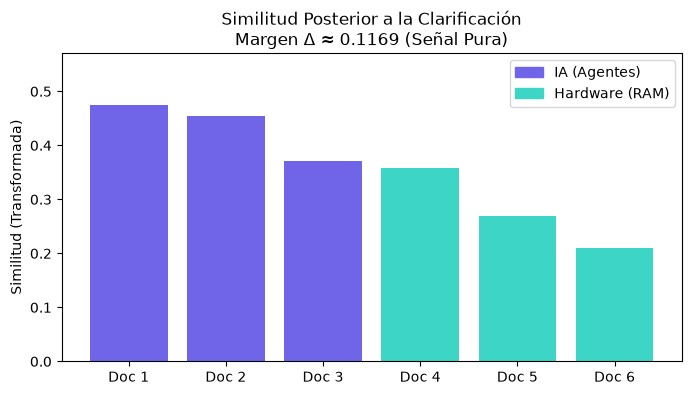

ÉXITO: Al aclarar la intención latente Z, el sistema recupera 100% señal relevante, eliminando el ruido y permitiendo una respuesta determinista.


In [20]:
# Simulamos que el usuario responde a la pregunta aclaratoria
user_clarification = "Me refiero a los modelos de inteligencia artificial."

print(f"👤 Respuesta del usuario: '{user_clarification}'\n")

# Context Engineering: Usamos el LLM para reescribir la consulta a una señal densa y purificada (Z)
rewrite_prompt = ChatPromptTemplate.from_messages([
    ("system", "Reescribe la consulta del usuario combinando la consulta original y su aclaración en una única frase de búsqueda altamente específica, técnica y libre de ambigüedad. No uses la palabra genérica que causó la ambigüedad si puedes evitarlo. Solo devuelve la nueva consulta sin comillas."),
    ("user", "Consulta original: {query}\nAclaración: {clarification}")
])
rewrite_chain = rewrite_prompt | llm
robust_query = rewrite_chain.invoke({"query": ambiguous_query, "clarification": user_clarification}).content

print(f"Nueva búsqueda vectorial con señal densa: '{robust_query}'\n")

robust_results = vector_store.similarity_search_with_score(robust_query, k=6)
robust_docs = []
robust_scores = []
robust_topics = []

for i, (doc, score) in enumerate(robust_results):
    robust_docs.append(f"Doc {i+1}")
    similarity = 1 - (score / 2)
    robust_scores.append(similarity)
    robust_topics.append(doc.metadata["topic"])
    print(f"[{doc.metadata['topic']}] Score L2: {score:.4f} | Cosine: {similarity:.4f} | {doc.page_content[:70]}...")

# Gráfico de similitudes (Margen Delta ampliado)
plt.figure(figsize=(8, 4))
colors = ['#7065E8' if t == 'ai_agents' else '#3DD6C6' for t in robust_topics]
bars = plt.bar(robust_docs, robust_scores, color=colors)

# Calcular nuevo Delta real
try:
    robust_score_ai = max([s for s, t in zip(robust_scores, robust_topics) if t == 'ai_agents'])
    robust_score_hw = max([s for s, t in zip(robust_scores, robust_topics) if t == 'hardware'])
    new_delta = abs(robust_score_ai - robust_score_hw)
except ValueError:
    new_delta = 0

plt.title(f"Similitud Posterior a la Clarificación\nMargen Δ ≈ {new_delta:.4f} (Señal Pura)")
plt.ylabel("Similitud (Transformada)")
plt.ylim(0, max(robust_scores) * 1.2)
plt.legend(handles=[ai_patch, hw_patch])
plt.show()

print("ÉXITO: Al aclarar la intención latente Z, el sistema recupera 100% señal relevante, eliminando el ruido y permitiendo una respuesta determinista.")

